Kd (apparent, in equivalents) = 1.2355 ± 0.1091
Hill coefficient n = 1.7307 ± 0.3444
R² = 0.8856


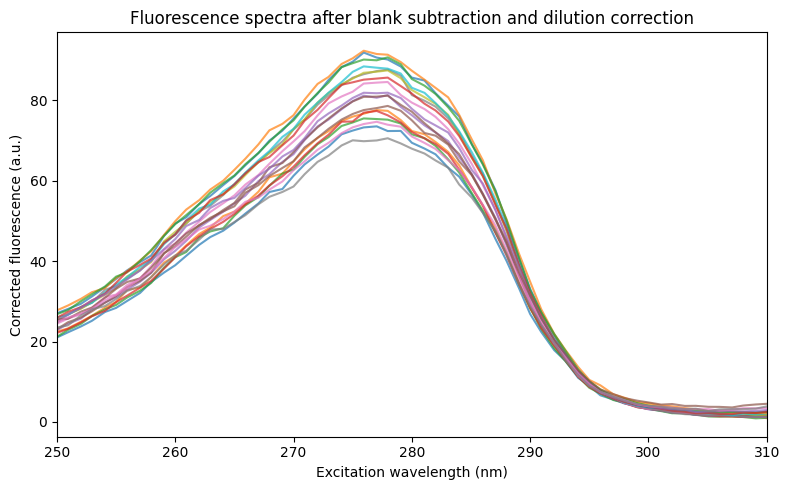

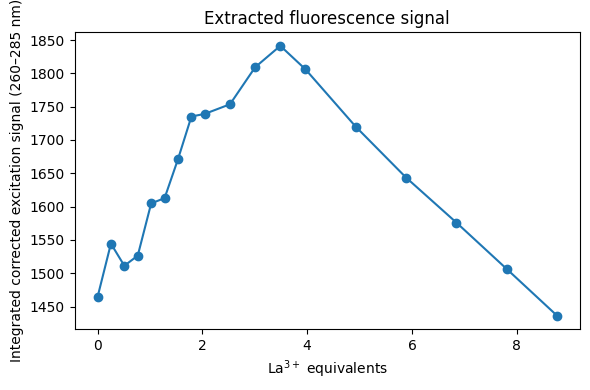

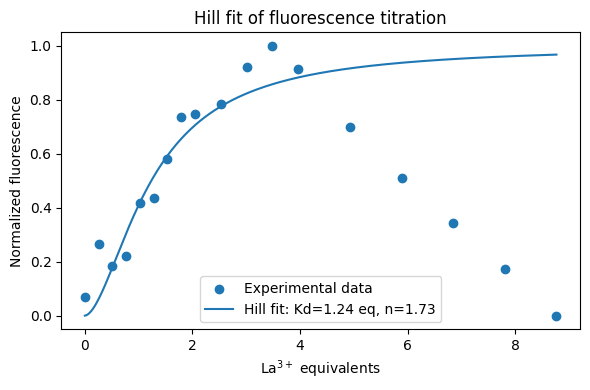

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

# ==============================
# PARAMETRES EXPERIMENTAUX
# ==============================

# Equivalents donnés dans le protocole
equiv = np.array([
    0.000, 0.256, 0.512, 0.768, 1.024, 1.280, 1.536, 1.792, 2.048,
    2.528, 3.008, 3.488, 3.968, 4.928, 5.888, 6.848, 7.808, 8.768
], dtype=float)

# Volumes totaux donnés dans le protocole (µL)
volumes = np.array([
    3000, 3008, 3016, 3024, 3032, 3040, 3048, 3056, 3064,
    3079, 3094, 3109, 3124, 3154, 3184, 3214, 3244, 3274
], dtype=float)

V0 = 3000.0  # volume initial en µL

# Dossier contenant les CSV
data_dir = Path("Data fluorescence") / "320nm"

# ==============================
# LECTURE D'UN FICHIER
# ==============================

def read_spectrum(file_path):
    df = pd.read_csv(file_path, skiprows=2, header=None, usecols=[0, 1])
    df.columns = ["wavelength", "intensity"]
    return df

# ==============================
# LECTURE DU BLANC
# ==============================

blank_file = data_dir / "buffer_method_320nm.csv"
blank_df = read_spectrum(blank_file)

wavelength = blank_df["wavelength"].to_numpy()
blank_intensity = blank_df["intensity"].to_numpy()

# ==============================
# TRAITEMENT DES 18 SPECTRES
# ==============================

signals = []
all_corrected = []

for i in range(1, 19):
    file_path = data_dir / f"{i}_method_320nm.csv"
    df = read_spectrum(file_path)

    # Vérification simple
    if not np.allclose(df["wavelength"].to_numpy(), wavelength):
        raise ValueError(f"Wavelength mismatch in file {file_path.name}")

    intensity = df["intensity"].to_numpy()

    # 1) Soustraction du blanc
    corrected = intensity - blank_intensity

    # 2) Correction de dilution
    corrected = corrected * (volumes[i-1] / V0)

    all_corrected.append(corrected)

    # 3) Extraction d'un signal représentatif
    mask = (wavelength >= 260) & (wavelength <= 285)
    signal = np.trapezoid(corrected[mask], wavelength[mask])
    signals.append(signal)

signals = np.array(signals)
all_corrected = np.array(all_corrected)

# ==============================
# NORMALISATION
# ==============================

theta = (signals - signals.min()) / (signals.max() - signals.min())

# Si la courbe décroît au lieu de croître, inverser :
# theta = 1 - theta

# ==============================
# MODELE DE HILL
# ==============================

def hill_model(L, Kd, n):
    return (L**n) / (Kd**n + L**n)

# Guess initial
p0 = [2.0, 1.0]

# only the initial part of the titration curve (0–3 equivalents) was used for fitting
mask_fit = equiv <= 3
#mask_fit = np.ones_like(equiv, dtype=bool)

# Fit uniquement sur cette zone
popt, pcov = curve_fit(
    hill_model,
    equiv[mask_fit],
    theta[mask_fit],
    p0=p0,
    bounds=(0, np.inf),
    maxfev=20000
)

Kd_fit, n_fit = popt
err = np.sqrt(np.diag(pcov))
Kd_err, n_err = err

# R²
theta_fit_local = hill_model(equiv[mask_fit], *popt)
ss_res = np.sum((theta[mask_fit] - theta_fit_local)**2)
ss_tot = np.sum((theta[mask_fit] - np.mean(theta[mask_fit]))**2)
r2 = 1 - ss_res / ss_tot

print(f"Kd (apparent, in equivalents) = {Kd_fit:.4f} ± {Kd_err:.4f}")
print(f"Hill coefficient n = {n_fit:.4f} ± {n_err:.4f}")
print(f"R² = {r2:.4f}")

# ==============================
# PLOTS
# ==============================

# 1) Spectres corrigés
plt.figure(figsize=(8,5))
for i in range(18):
    plt.plot(wavelength, all_corrected[i], alpha=0.7, label=f"{equiv[i]:.3f} eq")
plt.xlabel("Excitation wavelength (nm)")
plt.ylabel("Corrected fluorescence (a.u.)")
plt.title("Fluorescence spectra after blank subtraction and dilution correction")
plt.xlim(wavelength.min(), wavelength.max())
plt.tight_layout()
plt.show()

# 2) Signal extrait
plt.figure(figsize=(6,4))
plt.plot(equiv, signals, "o-")
plt.xlabel("La$^{3+}$ equivalents")
plt.ylabel("Integrated corrected excitation signal (260–285 nm)")
plt.title("Extracted fluorescence signal")
plt.tight_layout()
plt.show()

# 3) Fit de Hill
x_fit = np.linspace(equiv.min(), equiv.max(), 300)
y_fit = hill_model(x_fit, *popt)

plt.figure(figsize=(6,4))
plt.scatter(equiv, theta, label="Experimental data")
plt.plot(x_fit, y_fit, label=f"Hill fit: Kd={Kd_fit:.2f} eq, n={n_fit:.2f}")
plt.xlabel("La$^{3+}$ equivalents")
plt.ylabel("Normalized fluorescence")
plt.title("Hill fit of fluorescence titration")
plt.legend()
plt.tight_layout()
plt.show()